In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/elevator_with_lags.csv")

In [3]:
df.head()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5,Hour_Bin,vib_lag1,vib_lag4,vib_lag16,vib_lag32,rev_lag1,rev_lag4
0,33,93.621,73.989,18.03,167.610,19.632,1.265337,8764.891641,5474.372121,1,18.03,18.03,18.02,18.0,93.624,93.636
1,34,93.617,73.988,18.03,167.605,19.629,1.265300,8764.142689,5474.224144,1,18.03,18.03,18.02,18.0,93.621,93.632
2,35,93.613,73.988,18.03,167.601,19.625,1.265246,8763.393769,5474.224144,1,18.03,18.00,18.02,18.0,93.617,93.628
3,36,93.609,73.988,18.04,167.597,19.621,1.265192,8762.644881,5474.224144,1,18.03,18.03,18.02,18.0,93.613,93.624
4,37,93.605,73.987,18.04,167.592,19.618,1.265155,8761.896025,5474.076169,1,18.04,18.03,18.00,18.0,93.609,93.621


In [4]:
# =============================================================
# GOAL: Add "what has the vibration been doing recently?" features.
# Lag features tell the model the exact past value.
# Rolling features tell the model the TREND over recent seconds.
#
# WHAT IS A ROLLING STATISTIC?
# A rolling window moves through the data row by row.
# At each row, it looks at the last N rows and computes:
#   rolling MEAN = average of last N vibration values
#   rolling STD  = spread of last N vibration values
#
# Example with window = 4 (last 1 second):
#   Row 10: window = rows 7,8,9,10 → mean of their vibration
#   Row 11: window = rows 8,9,10,11 → mean of their vibration
#   ...moves forward one step at a time
#
# WHY IS THIS USEFUL?
# Lag features say "it was 35 one second ago."
# Rolling mean says "over the last 4 seconds, average was 33."
# Rolling std says "values have been very spread out (std=8)"
#   → High rolling std = vibration is unstable = potential problem
# =============================================================

In [5]:
lag_features_r2 = 0.5931
lag_features_mae = 3.4104

In [6]:
# rolling mean and std form over last 16 rows
df['roll_mean_16'] = df['vibration'].rolling(window = 16).mean()
df['roll_std_16'] = df['vibration'].rolling(window = 16).std()

# rolling mean and std from over last 64 rows
df['roll_mean_64'] = df['vibration'].rolling(window = 64).mean()
df['roll_std_64'] = df['vibration'].rolling(window = 64).std()

# max vibration in last 16 rows
df['roll_max_16'] = df['vibration'].rolling(window = 16).max()

df = df.dropna().reset_index(drop=True)

In [7]:
df.head()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5,Hour_Bin,...,vib_lag4,vib_lag16,vib_lag32,rev_lag1,rev_lag4,roll_mean_16,roll_std_16,roll_mean_64,roll_std_64,roll_max_16
0,96,93.377,73.968,18.1,167.345,19.409,1.262397,8719.264129,5471.265024,1,...,18.09,18.08,18.06,93.381,93.393,18.076875,0.030489,18.057813,0.026032,18.1
1,97,93.374,73.968,18.1,167.342,19.406,1.262357,8718.703876,5471.265024,1,...,18.09,18.00,18.06,93.377,93.389,18.083125,0.023013,18.058906,0.026314,18.1
2,98,93.370,73.967,18.1,167.337,19.403,1.262320,8717.956900,5471.117089,1,...,18.09,18.08,18.07,93.374,93.385,18.084375,0.023372,18.060000,0.026547,18.1
3,99,93.366,73.967,18.1,167.333,19.399,1.262266,8717.209956,5471.117089,1,...,18.09,18.08,18.07,93.370,93.381,18.085625,0.023656,18.061094,0.026733,18.1
4,100,93.362,73.967,18.1,167.329,19.395,1.262212,8716.463044,5471.117089,1,...,18.10,18.08,18.07,93.366,93.377,18.086875,0.023866,18.062031,0.027032,18.1


In [8]:
# Feature List
original_features = [
    "revolutions","humidity",
    "x1","x2","x3","x4","x5"
]

lag_features = [
    "vib_lag1",
    "vib_lag4",
    "vib_lag16",
    "vib_lag32",
    "rev_lag1",
    "rev_lag4"
]

rolling_features = [
    "roll_mean_16",
    "roll_std_16",
    "roll_mean_64",
    "roll_std_64",
    "roll_max_16"
]

all_features = (
    original_features
    + lag_features
    + rolling_features
)

In [9]:
# Temporal Split of data
X = df[all_features]
y = df['vibration']
split = int(len(df) * 0.8)

X_train, X_test = X[:split],X[split:]
y_train, y_test = y[:split],y[split:]

In [10]:
# setting up the random forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train,y_train)

pred = rf_model.predict(X_test)

In [11]:
# evaluation 
mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 2.9792255595855504
RMSE : 7.378123483933775
R2 : 0.7449624965478825


In [12]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature' : all_features,
    'Importance' : importance * 100
})

feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)
print(feature_importance)

         Feature  Importance
9      vib_lag16   83.038084
10     vib_lag32    7.346690
8       vib_lag4    5.715192
13  roll_mean_16    1.547070
14   roll_std_16    0.661725
15  roll_mean_64    0.326849
17   roll_max_16    0.324649
16   roll_std_64    0.210483
7       vib_lag1    0.174539
1       humidity    0.127494
6             x5    0.123658
2             x1    0.085559
3             x2    0.082072
12      rev_lag4    0.055090
5             x4    0.047458
11      rev_lag1    0.047231
0    revolutions    0.043159
4             x3    0.042997


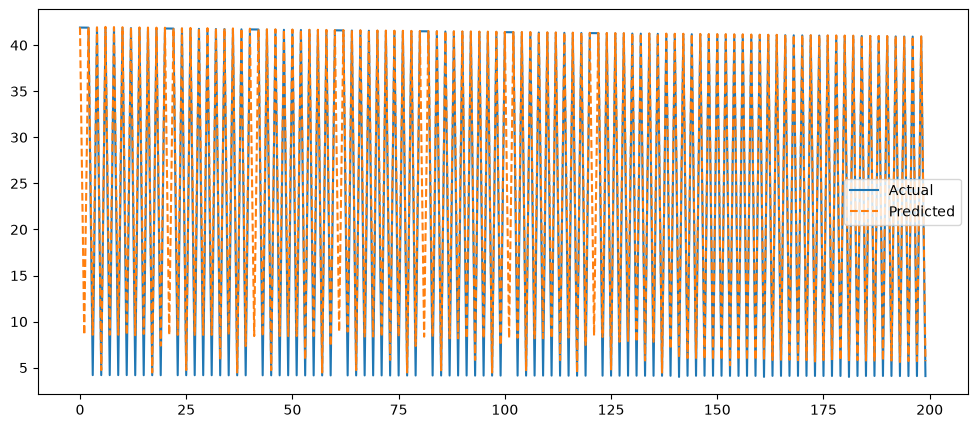

In [13]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(pred[:200], "--", label="Predicted")

plt.legend()
plt.show()

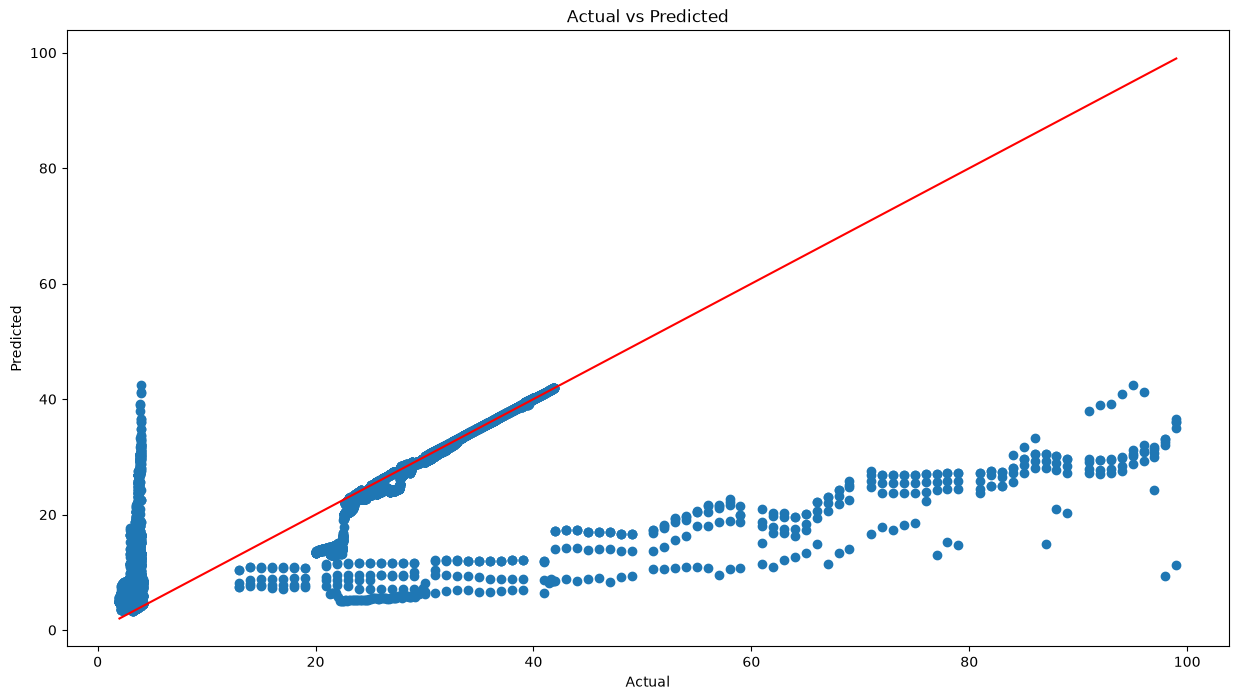

In [14]:
plt.figure(figsize=(15,8))

plt.scatter(y_test, pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

count    111906.000000
mean         28.636441
std          24.536526
min           2.000000
25%           8.000000
50%          21.330000
75%          39.670000
max         100.000000
Name: vibration, dtype: float64


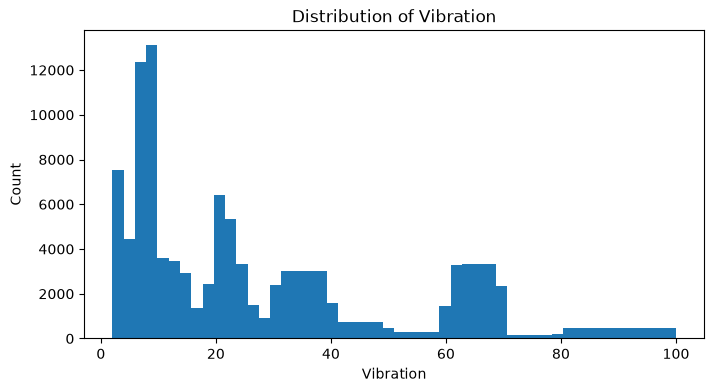

In [15]:
print(df["vibration"].describe())

plt.figure(figsize=(8,4))
plt.hist(df["vibration"], bins=50)
plt.title("Distribution of Vibration")
plt.xlabel("Vibration")
plt.ylabel("Count")
plt.show()

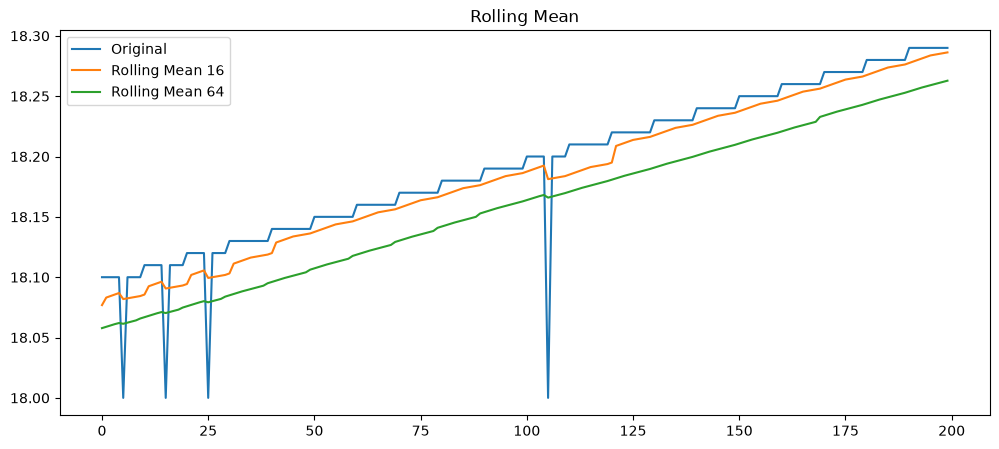

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    df["vibration"][:200],
    label="Original"
)

plt.plot(
    df["roll_mean_16"][:200],
    label="Rolling Mean 16"
)

plt.plot(
    df["roll_mean_64"][:200],
    label="Rolling Mean 64"
)

plt.title("Rolling Mean")

plt.legend()

plt.show()

In [17]:
# evaluation comparison with lag_features models evaluation
print(f"Evaluation metrics for lag features model:")
print(f"MAE: {lag_features_mae:.4f}")
print(f"R2: {lag_features_r2:.4f}") 
print(f"Evaluation metrics for rolling stats model:")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

Evaluation metrics for lag features model:
MAE: 3.4104
R2: 0.5931
Evaluation metrics for rolling stats model:
MAE: 2.9792
R2: 0.7450


In [18]:
import joblib

joblib.dump(rf_model,'rf_model.pkl')
df.to_csv("../data/processed/elevator_with_rolling_stats.csv",index=False)

###
The baseline Random Forest model performed poorly because it relied only on current sensor readings and had no temporal information. To overcome this limitation, lag features were introduced, allowing the model to use previous vibration and motor speed values. This significantly improved the prediction accuracy, increasing the R² score from −0.3066 to 0.5931 while reducing the MAE from 15.37 to 3.41. In the next phase, rolling statistical features were added to capture short-term trends in the sensor data. These features provided additional contextual information, enabling the model to learn the overall behaviour of the elevator rather than relying on individual previous readings. As a result, the model achieved its best performance with an MAE of 2.98 and an R² score of 0.7450, indicating that it explains approximately 75% of the variation in vibration. This demonstrates that combining temporal memory with rolling statistical summaries substantially improves predictive maintenance performance.
###